# Vainshtein Screening
This notebook demonstrates the Vainshtein screening mechanism using the unified scalar BVP solver:
- **§1** — Single solve: full nonlinear vs linearised reference, with estimated Vainshtein radius.
- **§2** — Sweep over central overdensity $\delta_c$: slope $n(x) = d\ln[x^2|Q_x|]/d\ln x$ coloured by $\log_{10}(\delta_c)$, with Vainshtein radii marked.

Note: This notebook reads modules directly from `../main` so you can run it inside this repo without installing a package.

In [44]:
# Setup: import local modules from ../main
import sys, os, importlib
repo_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
main_dir = os.path.join(repo_root, "main")
if main_dir not in sys.path:
    sys.path.insert(0, main_dir)
print("Added to sys.path:", main_dir)

# Reload dependency chain: physics_utils → plotting → escut
import physics_utils as _physics_mod
importlib.reload(_physics_mod)
import plotting as _plotting_mod
importlib.reload(_plotting_mod)
import escut
importlib.reload(escut)

# Single-surface import: pull everything from escut
from escut import (
    # core solver
    solve_scalar_bvp,
    # plotting helpers
    plot_double_panel,
    compute_n_slope,
)

import numpy as np
import matplotlib.pyplot as plt

Added to sys.path: /Users/sergi/Qsolver/main


## 1) Simple case: full vs linear
We solve with Vainshtein coefficient $F>0$ and compare to a linearised ($F=0$) reference.
The Vainshtein radius $x_V$ is estimated from where the nonlinear-to-linear flux ratio crosses 1.

/Users/sergi/Qsolver/main/physics_utils.py:131: RuntimeWarning: invalid value encountered in scalar divide
  Physics:
/Users/sergi/Qsolver/main/plotting.py:229: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  _setup_delta_c_colormap = _cmap_setup


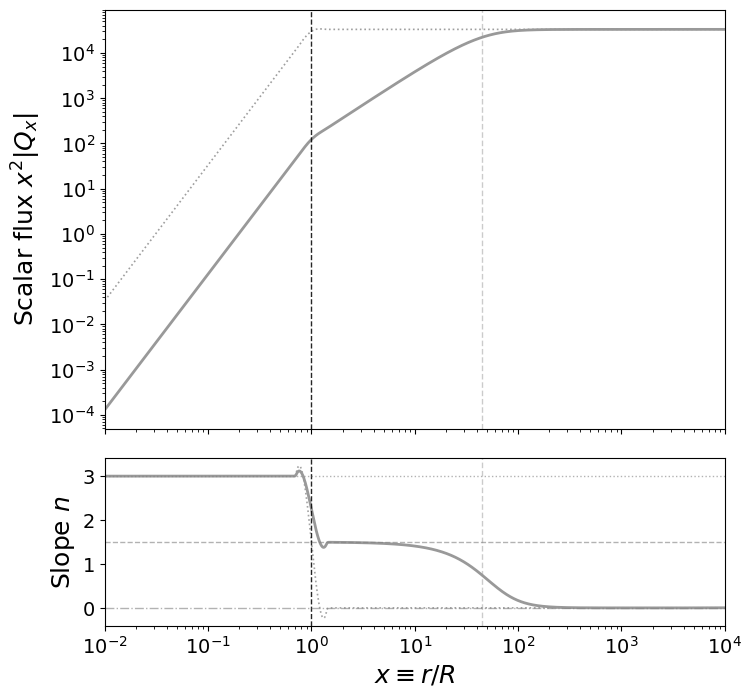

In [45]:
A = 1.0
B = 0
C = 0
F = 1e0
S = 1.0
delta_c   = 1e5
delta_inf = 1e-10
eps_edge  = 0.015

common_kwargs = dict(
    S=S, delta_c=delta_c, delta_inf=delta_inf,
    xmin=1e-4, xmax=1e5, npoints=2500,
    Q_inf=0.0, homotopy=False, tol=1e-8, max_nodes=2_000_000,
    eps_edge=eps_edge,
)

sol_linear = solve_scalar_bvp(A=A, B=B, C=0, D=0, E=0, F=0, **common_kwargs)
sol_full   = solve_scalar_bvp(A=A, B=B, C=C, D=0, E=0, F=F, **common_kwargs)

x_plot_min = 1e-2
x_plot_max = 1e4
x = np.logspace(np.log10(x_plot_min), np.log10(x_plot_max), 1200)
plot_double_panel(x, [sol_full], linrefs=[sol_linear], smooth_win_deriv=61, smooth_win_vain=61)
plt.show()

## 2) Sweep over δc and publication plot
We vary the central overdensity $\delta_c$ over a decade grid, solve for each, and produce the
double-panel figure (flux on top, slope $n(x)$ on bottom) coloured by $\log_{10}(\delta_c)$.

In [46]:
# Stabilized δc sweep settings
A = 1.0
F = 1
S = 1.0
delta_inf = 1e-10
eps_edge = 0.015

# Cropped domain and lighter mesh to avoid excessive refinement
xmin, xmax = 1e-2, 1e6
npoints = 800
tol = 1e-6
max_nodes = 1_000_000

# Define a sweep of delta_c values
delta_cs = np.logspace(5, 10, 6)  # 1e5 .. 1e10
sols = []
linrefs = []
for dc in delta_cs:
    sol = solve_scalar_bvp(A=A, B=0.0, C=0.0, D=0.0, E=0.0, F=F,
                           S=S, delta_c=dc, delta_inf=delta_inf, eps_edge=eps_edge,
                           xmin=xmin, xmax=xmax, npoints=npoints, tol=tol, homotopy=False, max_nodes=max_nodes)
    sols.append(sol)
    sol_lin = solve_scalar_bvp(A=A, B=0.0, C=0.0, D=0.0, E=0.0, F=0.0,
                               S=S, delta_c=dc, delta_inf=delta_inf, eps_edge=eps_edge,
                               xmin=xmin, xmax=xmax, npoints=npoints, tol=tol, homotopy=False, max_nodes=max_nodes)
    linrefs.append(sol_lin)

/Users/sergi/Qsolver/main/plotting.py:229: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  _setup_delta_c_colormap = _cmap_setup


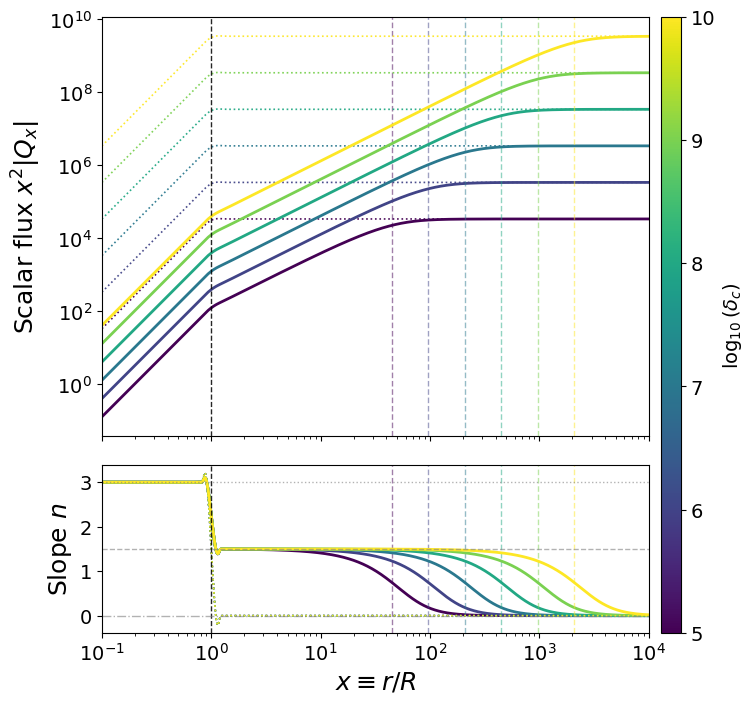

In [48]:
x_plot_min = 1e-1
x_plot_max = 1e4
x = np.logspace(np.log10(x_plot_min), np.log10(x_plot_max), 1200)

fig, (ax_top, ax_bot), xV_map = plot_double_panel(
    x, sols, linrefs=linrefs, cmap_name="viridis",
    lw_num=2.0, lw_lin=1.2, lin_ls=":",
    smooth_win_deriv=61, smooth_poly_deriv=3,
    vradius="full", vline_alpha=0.5, vline_lw=1.0, vline_ls="striped",
)
plt.show()